<a href="https://colab.research.google.com/github/emzu/futureIDF/blob/main/8)Effective_Return_Periods.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import drive
drive.mount('/content/drive')

!git config --global user.email "ezuetell@andrew.cmu.edu"
!git config --global user.name "emzu"

try:
    !git clone "https://github.com/emzu/futureIDF"
except:
    print("Already cloned")

%cd /content/futureIDF
!git pull

# Load Packages
!pip install -r requirements.txt

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
fatal: destination path 'futureIDF' already exists and is not an empty directory.
/content/futureIDF
Already up to date.


In [2]:
!git pull

# Import modules
import sys
import importlib
# Ensure workspace root is on sys.path so the local `modules` package can be imported
sys.path.append('..')

import numpy as np
import matplotlib.pyplot as plt
import xarray as xr
import glob
import os
import warnings
warnings.filterwarnings('ignore')

from modules import config, data_io, timeseries, plotting, process_rp, geospatial
importlib.reload(timeseries)
importlib.reload(data_io)
importlib.reload(process_rp)
importlib.reload(geospatial)

Already up to date.


<module 'modules.geospatial' from '/content/futureIDF/modules/geospatial.py'>

In [3]:
import pandas as pd
import geopandas as gpd

counties = data_io.load_counties()

atlas14 = pd.read_parquet('/content/atlas14_24hr_data.parquet')
a14_points = gpd.GeoDataFrame(
    atlas14,
    geometry=gpd.points_from_xy(atlas14['lon'], atlas14['lat']))
atlas14_counties = gpd.sjoin(a14_points, counties, how = 'left', predicate = 'within')

In [4]:
#Load Data
check_LOCA = xr.open_zarr("/content/drive/MyDrive/Research/MARISA_IDF/data/FINAL/FINAL_COMBINED/adj_factors_combined_LOCA_lmom_smoothedcentroid_nb100_1950_2000.zarr", consolidated = False)
check_LOCA2 = xr.open_zarr("/content/drive/MyDrive/Research/MARISA_IDF/data/FINAL/FINAL_COMBINED/adj_factors_combined_LOCA2_lmom_smoothedcentroid_nb100_1950_2000.zarr", consolidated = False)

In [5]:
adjFactors_LOCA = check_LOCA.sel(scenario = 'rcp45', time_period = '2050-2100').mean('centroid_cell')['adj_factor']
adjFactors_LOCA2 = check_LOCA2.sel(scenario = 'ssp245', time_period = '2050-2100').mean('centroid_cell')['adj_factor']

In [6]:
rps = np.array(config.RETURN_PERIODS).astype(str)

scen = 'ssp245'
a14_val = 'upper'
rps = ['2', '5', '10', '25', '50', '100', '200', '500']
result = []

for idx, county in counties.iterrows():
  print(county['NAME'])

  try:
    atlas14 = atlas14_counties[atlas14_counties['NAME']==county['NAME']].reset_index().iloc[0][rps].astype(float)
    print(atlas14)
    #Get effective climate data
    ds_zarr_LOCA2 = adjFactors_LOCA2.sel(county = str(counties[counties['NAME']==county['NAME']].index.values[0]))
    ds_zarr_LOCA2_45 = ds_zarr_LOCA2.median(dim = ['model', 'n_b'])

    #Get design values
    design_LOCA = adjFactors_LOCA.sel(county = str(counties[counties['NAME']==county['NAME']].index.values[0]))
    design_LOCA = design_LOCA.median(dim = ['model', 'n_b'])

    #Reference Design Factors
    design_factors_LOCA = design_LOCA.values
    ci_upper = atlas14_counties[atlas14_counties['NAME']==county['NAME']].reset_index().iloc[1][rps].astype(float)

    design_depths, values = timeseries.compute_county_exceedance(
        ds_zarr_LOCA2_45,
        atlas14[:6],
        #mode="change_factor",
        mode = "upper_ci",
        change_factors=design_factors_LOCA,
        ci_upper=ci_upper,
        n_rp=None,
    )
    print(values)

    result.append(values)
  except:
    result.append(np.nan)



Beaver
2      2.352
5      2.880
10     3.288
25     3.912
50     4.392
100    4.920
200    5.448
500    6.216
Name: 0, dtype: float64
2.520    1.000000
3.096    0.257163
3.552    0.136886
4.176    0.066277
4.704    0.041149
5.232    0.027457
dtype: float64
Salem
2      3.024
5      3.840
10     4.512
25     5.472
50     6.288
100    7.176
200    8.136
500    9.504
Name: 0, dtype: float64
3.288    1.000000
4.176    0.248547
4.896    0.131384
5.952    0.059346
6.840    0.033194
7.776    0.020341
dtype: float64
Montgomery
2      2.784
5      3.528
10     4.152
25     5.040
50     5.784
100    6.600
200    7.464
500    8.736
Name: 0, dtype: float64
3.000    1.000000
3.816    0.262819
4.488    0.139802
5.424    0.064972
6.240    0.034272
7.104    0.019462
dtype: float64
Poquoson
2       3.552
5       4.584
10      5.496
25      6.840
50      7.992
100     9.288
200    10.752
500    12.936
Name: 0, dtype: float64
3.888     1.000000
5.040     0.215147
6.024     0.109821
7.488     0.045361
8.

In [7]:
results_list = result
expected_len = max(len(v) for v in results_list if not (isinstance(v, float) and np.isnan(v)))

results_fixed = [
    np.full(expected_len, np.nan) if (isinstance(v, float) and np.isnan(v)) else v
    for v in results_list
]

results_array = np.array(results_fixed)

In [8]:
risk_25 = results_array

In [9]:
recurInt_a14Design10per = 1/(pd.DataFrame(risk_25, columns = rps[:6]))
counties[rps[:6]] = recurInt_a14Design10per

In [11]:
triple_check

,STATEFP,NAME,geometry,STATE,2,5,10,25,50,100
0,42,Beaver,"POLYGON ((-80.15522 40.78819, -80.15521 40.788...",PA,1.000000,3.888586,7.305371,15.088098,24.302010,36.420150
1,51,Salem,"POLYGON ((-80.12049 37.28705, -80.12015 37.287...",VA,1.000000,4.023379,7.611299,16.850451,30.125950,49.162066
2,51,Montgomery,"MULTIPOLYGON (((-80.53306 37.26508, -80.53289 ...",VA,1.000000,3.804893,7.152959,15.391331,29.178418,51.381484
3,51,Poquoson,"POLYGON ((-76.41356 37.13856, -76.4132 37.1394...",VA,1.000000,4.647976,9.105707,22.045131,43.270525,77.182453
4,51,James City,"POLYGON ((-76.73855 37.26132, -76.73851 37.261...",VA,1.000000,4.783435,9.482976,22.640153,43.097049,73.585004
...,...,...,...,...,...,...,...,...,...,...
257,36,Ontario,"MULTIPOLYGON (((-77.36988 42.57637, -77.37089 ...",NY,2.492672,6.728166,14.099282,54.670686,inf,inf
258,36,Madison,"POLYGON ((-75.68749 42.73399, -75.68774 42.733...",NY,1.000000,3.594279,6.765387,15.123767,26.370273,43.912426
259,36,Onondaga,"MULTIPOLYGON (((-76.08337 42.7799, -76.08507 4...",NY,2.704659,6.905069,13.957930,41.743711,81.935356,inf
260,36,Oneida,"POLYGON ((-75.20936 42.96071, -75.20919 42.958...",NY,2.688246,6.529133,12.924410,37.435016,75.372588,inf


In [10]:


double_check = counties
triple_check = geospatial.interp_nearest_neighbors(double_check)
triple_check.to_parquet(f"/content/drive/MyDrive/Research/MARISA_IDF/data/recurInt_LOCA2_Design_upper_CI")

In [21]:
from shapely import wkb

In [24]:
DATA_DIR = "/content/drive/MyDrive/Research/MARISA_IDF/data"

SOURCES = {
    "a14_step_up_LOCA2": "recurInt_a14_step_up_Design_LOCA2",
    "a14_step_up_LOCA":  "recurInt_a14_step_up_Design_LOCA",
    "a14_LOCA":          "recurInt_a14Design_LOCA",
    "a14_LOCA2":         "recurInt_a14Design_LOCA2",
    "loca_adj_LOCA2":    "recurInt_LOCA_Design_LOCA2",
    "loca_adj_LOCA":     "recurInt_LOCA_Design_LOCA",
    "upCI_adj_LOCA":     "recurInt_LOCA_Design_upper_CI",
    "upCI_adj_LOCA2":    "recurInt_LOCA2_Design_upper_CI",
}

dfs = {}
for return_period in [10, 50]:
    rp = str(return_period)

    loaded = {col: pd.read_parquet(f"{DATA_DIR}/{fname}") for col, fname in SOURCES.items()}
    first = next(iter(loaded.values()))

    # Fix WKB-encoded geometry if needed
    first["geometry"] = first["geometry"].apply(lambda g: wkb.loads(g) if isinstance(g, bytes) else g)

    frames = {col: df[rp] for col, df in loaded.items()}
    frames["NAME"]     = first["NAME"]
    frames["geometry"] = first["geometry"]

    dfs[return_period] = gpd.GeoDataFrame(frames, geometry="geometry")
df_10yr = dfs[10]
df_50yr = dfs[50]

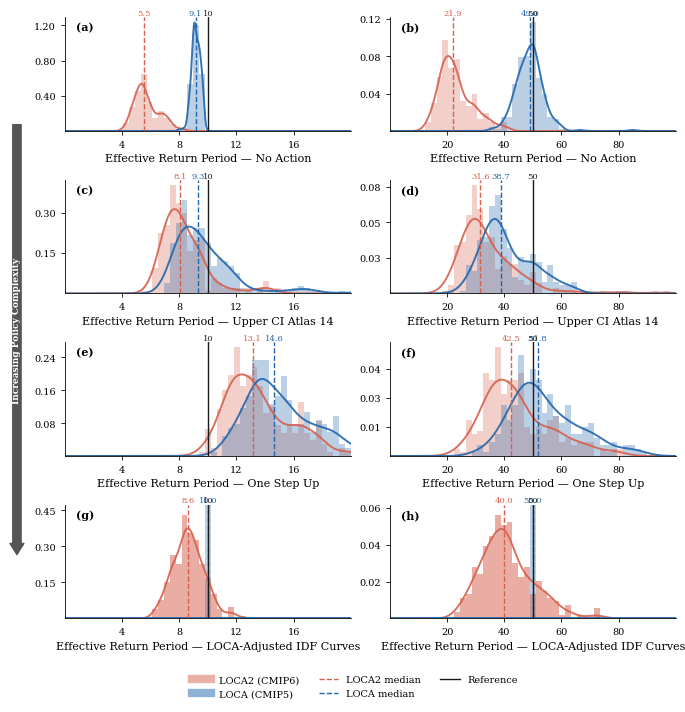

In [41]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from matplotlib.lines import Line2D
from scipy.stats import gaussian_kde
from matplotlib.patches import FancyArrowPatch

plt.rcParams.update({
    "font.family":       "serif",
    "font.serif":        ["Times New Roman", "DejaVu Serif"],
    "font.size":         8,
    "axes.labelsize":    8,
    "axes.titlesize":    9,
    "xtick.labelsize":   7,
    "ytick.labelsize":   7,
    "legend.fontsize":   7,
    "axes.linewidth":    0.6,
    "xtick.major.width": 0.6,
    "ytick.major.width": 0.6,
    "xtick.minor.width": 0.4,
    "ytick.minor.width": 0.4,
    "xtick.direction":   "out",
    "ytick.direction":   "out",
    "xtick.major.size":  3,
    "ytick.major.size":  3,
    "axes.spines.top":   False,
    "axes.spines.right": False,
    "pdf.fonttype":      42,
    "ps.fonttype":       42,
})

C_LOCA   = "#2166ac"
C_LOCA2  = "#d6604d"
C_REF    = "#1a1a1a"
ALPHA_HIST = 0.30
ALPHA_KDE  = 0.90

datasets = [
    ('a14_LOCA2', 'a14_LOCA', 'No Action'),
    ('upCI_adj_LOCA2', 'upCI_adj_LOCA', 'Upper CI Atlas 14'),
    ('a14_step_up_LOCA2', 'a14_step_up_LOCA', 'One Step Up'),
    ('loca_adj_LOCA2',    'loca_adj_LOCA',     'LOCA-Adjusted IDF Curves'),
]
return_periods = [
    (df_10yr, '10-yr', 10,  np.linspace(0, 20,  50), (0, 20)),
    (df_50yr, '50-yr', 50,  np.linspace(0, 100, 50), (0, 100)),

]
panel_labels = [["(a)", "(b)"], ["(c)", "(d)"], ["(e)", "(f)"], ["(g)", "(h)"]]

fig, axes = plt.subplots(4, 2, figsize=(6.5, 6.5),
                         constrained_layout=True)

for row, (col1, col2, row_title) in enumerate(datasets):
    for col, (df, rp_title, ref, bins, xlim) in enumerate(return_periods):
        ax = axes[row, col]

        glue = df[['NAME', col1, col2]].set_index('NAME')
        d1   = glue[col1].dropna().values   # LOCA2
        d1   = d1[np.isfinite(d1)]
        d2   = glue[col2].dropna().values   # LOCA
        d2   = d2[np.isfinite(d2)]

        # ── histograms ────────────────────────────────────────────────────────
        ax.hist(d1, bins=bins, density=True,
                color=C_LOCA2, alpha=ALPHA_HIST, linewidth=0)
        ax.hist(d2, bins=bins, density=True,
                color=C_LOCA,  alpha=ALPHA_HIST, linewidth=0)

        # ── KDE curves ───────────────────────────────────────────────────────
        x_grid = np.linspace(xlim[0], xlim[1], 400)
        for data, color in [(d1, C_LOCA2), (d2, C_LOCA)]:
            kde = gaussian_kde(data, bw_method="scott")
            ax.plot(x_grid, kde(x_grid), color=color, lw=1.4, alpha=ALPHA_KDE)

        # ── median lines ─────────────────────────────────────────────────────
        for data, color in [(d1, C_LOCA2), (d2, C_LOCA)]:
            med = np.median(data)
            ax.axvline(med, color=color, lw=1.0, ls="--", zorder=4)
            ax.text(med, 1.0, f"{med:.1f}",
                    color=color, fontsize=6, ha="center", va="bottom",
                    transform=ax.get_xaxis_transform())

        # ── reference line ───────────────────────────────────────────────────
        ax.axvline(ref, color=C_REF, lw=1.0, ls="-", zorder=5)
        ax.text(ref, 1.0, f"{ref}",
                color=C_REF, fontsize=6, ha="center", va="bottom",
                transform=ax.get_xaxis_transform())

        # ── labels & formatting ──────────────────────────────────────────────
        ax.set_xlim(*xlim)
        ax.set_xlabel(f"Effective Return Period — {row_title}", labelpad=3)
        ax.set_ylabel("" if col == 0 else "")
        ax.xaxis.set_major_locator(ticker.MaxNLocator(5, prune="both"))
        ax.yaxis.set_major_locator(ticker.MaxNLocator(4, prune="both"))
        ax.yaxis.set_major_formatter(ticker.FormatStrFormatter("%.2f"))
        ax.text(0.04, 0.96, panel_labels[row][col], transform=ax.transAxes,
                fontsize=8, fontweight="bold", va="top", ha="left")

        if row_title == "LOCA-Adjusted IDF Curves":
          counts, bins, _ = ax.hist(d1, bins=bins, density=True,
                color=C_LOCA2, alpha=ALPHA_HIST, linewidth=0)
          ax.set_ylim(0, counts.max() * 1.1)
# ── shared legend ─────────────────────────────────────────────────────────────
handles = [
    Line2D([0], [0], color=C_LOCA2, lw=6, alpha=0.5, label="LOCA2 (CMIP6)"),
    Line2D([0], [0], color=C_LOCA,  lw=6, alpha=0.5, label="LOCA (CMIP5)"),
    Line2D([0], [0], color=C_LOCA2, lw=1.0, ls="--", label="LOCA2 median"),
    Line2D([0], [0], color=C_LOCA,  lw=1.0, ls="--", label="LOCA median"),
    Line2D([0], [0], color=C_REF,   lw=1.0, ls="-",  label="Reference"),
]
fig.legend(handles=handles, loc="lower center",
           bbox_to_anchor=(0.5, -0.08), ncol=3, frameon=False)

# ── policy complexity arrow ───────────────────────────────────────────────────
fig.patches.append(
    FancyArrowPatch(
        (-0.02, 0.82), (-0.02, 0.15),
        transform=fig.transFigure,
        arrowstyle="simple,head_width=10,head_length=8,tail_width=6",
        color="#555555",
        clip_on=False
    )
)

fig.text(-0.02, 0.5, "Increasing Policy Complexity",
         ha="center", va="center", fontsize=6.5, rotation=90,
         color="white", fontweight="bold",
         transform=fig.transFigure)

fig.savefig("design_storm_histograms.pdf", dpi=300, bbox_inches="tight")
fig.savefig("design_storm_histograms.png", dpi=300, bbox_inches="tight")
plt.show()

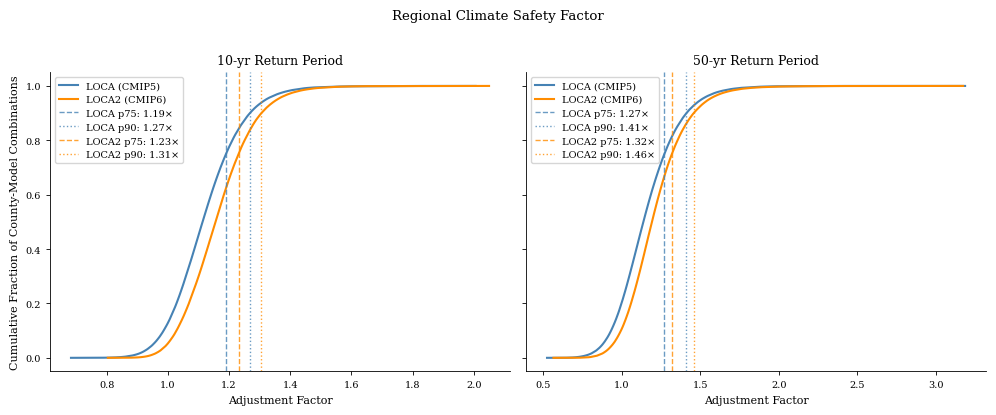

In [35]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4), sharey=True)

for ax, rp in zip(axes, [10, 50]):
    loca_vals  = adjFactors_LOCA.sel(return_periods=rp).values
    loca2_vals = adjFactors_LOCA2.sel(return_periods=rp).values

    loca_vals  = loca_vals[np.isfinite(loca_vals)].flatten()
    loca2_vals = loca2_vals[np.isfinite(loca2_vals)].flatten()

    loca_x,  loca_cdf  = empirical_cdf(loca_vals)
    loca2_x, loca2_cdf = empirical_cdf(loca2_vals)

    ax.plot(loca_x,  loca_cdf,  color='steelblue', lw=1.5, label='LOCA (CMIP5)')
    ax.plot(loca2_x, loca2_cdf, color='darkorange', lw=1.5, label='LOCA2 (CMIP6)')

    for vals, color, label in [(loca_vals, 'steelblue', 'LOCA'), (loca2_vals, 'darkorange', 'LOCA2')]:
        for p, ls in [(75, '--'), (90, ':')]:
            pval = np.percentile(vals, p)
            ax.axvline(pval, color=color, lw=1.0, linestyle=ls, alpha=0.8,
                       label=f'{label} p{p}: {pval:.2f}×')

    ax.set_xlabel("Adjustment Factor")
    ax.set_title(f"{rp}-yr Return Period")
    ax.legend(fontsize=7)

axes[0].set_ylabel("Cumulative Fraction of County-Model Combinations")
fig.suptitle("Regional Climate Safety Factor", y=1.02)
plt.tight_layout()